# Obj to spikes

In [1]:
from utils import load_it_data, evaluation_metrics

it_data_dir = '.'
stimulus_train, stimulus_val, stimulus_test, objects_train, objects_val, objects_test, spikes_train, spikes_val = load_it_data(it_data_dir)

In [4]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder

class ObjectsDataset(Dataset):
    def __init__(self, objects, spikes, device):
        self.objects = torch.tensor(objects, dtype=torch.long, device=device)
        self.spikes = torch.tensor(spikes, dtype=torch.float32, device=device)

    def __len__(self):
        return len(self.objects)

    def __getitem__(self, idx):
        obj = self.objects[idx]
        spike = self.spikes[idx]
        return obj, spike

    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

label_encoder = LabelEncoder()
objects_train_encoded = label_encoder.fit_transform(objects_train)
objects_val_encoded = label_encoder.fit_transform(objects_val)
num_classes = len(label_encoder.classes_)

train_dataset = ObjectsDataset(objects_train_encoded, spikes_train, device)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

val_inputs = torch.tensor(objects_val_encoded, dtype=torch.long, device=device)
val_targets = torch.tensor(spikes_val, dtype=torch.float32, device=device)

# Display 1st batch shape
for objects_batch, spikes_batch in train_loader:
    print(f"Spikes batch shape: {objects_batch.shape}")
    print(f"Spikes batch shape: {spikes_batch.shape}")
    print(f"Num classes: {num_classes}")
    break

Using device: cpu
Spikes batch shape: torch.Size([8])
Spikes batch shape: torch.Size([8, 168])
Num classes: 64


In [11]:
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

def calculate_metrics(predictions, targets):
    """
    Calcule et retourne des métriques d'évaluation pour les prédictions de spikes.
    
    Args:
        predictions: np.ndarray de forme [N, 168] - les prédictions du modèle
        targets: np.ndarray de forme [N, 168] - les valeurs cibles réelles
    
    Returns:
        dict: Dictionnaire contenant différentes métriques
    """
    n_neurons = predictions.shape[1]
    
    # Initialisation des arrays pour stocker les métriques par neurone
    correlations = np.zeros(n_neurons)
    explained_variances = np.zeros(n_neurons)
    mses = np.zeros(n_neurons)
    
    # Calcul des métriques pour chaque neurone
    for i in range(n_neurons):
        y_true = targets[:, i]
        y_pred = predictions[:, i]
        
        # Corrélation de Pearson
        corr, _ = pearsonr(y_true, y_pred)
        correlations[i] = corr
        
        # Variance expliquée (R²)
        y_true_mean = np.mean(y_true)
        ss_total = np.sum((y_true - y_true_mean) ** 2)
        ss_residual = np.sum((y_true - y_pred) ** 2)
        r2 = 1 - (ss_residual / ss_total) if ss_total != 0 else 0
        explained_variances[i] = max(0, r2)  # R² peut être négatif, le limiter à 0
        
        # MSE
        mses[i] = np.mean((y_true - y_pred) ** 2)
    
    # Calcul des statistiques globales
    metrics = {
        'correlation_mean': np.mean(correlations),
        'correlation_median': np.median(correlations),
        'explained_variance_mean': np.mean(explained_variances),
        'explained_variance_median': np.median(explained_variances),
        'mse_mean': np.mean(mses),
        'correlations': correlations,
        'explained_variances': explained_variances,
        'mses': mses
    }
    
    return metrics

def plot_metrics(metrics):
    """
    Affiche les histogrammes des métriques par neurone
    
    Args:
        metrics: dict - résultat de calculate_metrics
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Histogramme des corrélations
    axes[0].hist(metrics['correlations'], bins=20)
    axes[0].set_title(f"Corrélation (moyenne={metrics['correlation_mean']:.3f})")
    axes[0].set_xlabel("Corr")
    axes[0].set_ylabel("Nb of neurons")
    
    # Histogramme des variances expliquées
    axes[1].hist(metrics['explained_variances'], bins=20)
    axes[1].set_title(f"Variance expliquée (moyenne={metrics['explained_variance_mean']:.3f})")
    axes[1].set_xlabel("EV")
    axes[1].set_ylabel("Nb of neurons")
    
    # Histogramme des MSE
    axes[2].hist(metrics['mses'], bins=20)
    axes[2].set_title(f"MSE (moyenne={metrics['mse_mean']:.3f})")
    axes[2].set_xlabel("MSE")
    axes[2].set_ylabel("Nb of neurons")
    
    plt.tight_layout()
    plt.show()
    
    return fig

Epoch 1/20, Loss train: 0.1262, Loss val: 0.1187
EV: 0.1359, Corr: 0.3625
Epoch 2/20, Loss train: 0.1138, Loss val: 0.1146
EV: 0.1609, Corr: 0.3911
Epoch 3/20, Loss train: 0.1111, Loss val: 0.1137
EV: 0.1663, Corr: 0.3986
Epoch 4/20, Loss train: 0.1099, Loss val: 0.1135
EV: 0.1692, Corr: 0.4020
Epoch 5/20, Loss train: 0.1093, Loss val: 0.1134
EV: 0.1667, Corr: 0.4027
Epoch 6/20, Loss train: 0.1088, Loss val: 0.1122
EV: 0.1748, Corr: 0.4091
Epoch 7/20, Loss train: 0.1089, Loss val: 0.1121
EV: 0.1751, Corr: 0.4079
Epoch 8/20, Loss train: 0.1085, Loss val: 0.1129
EV: 0.1708, Corr: 0.4018
Epoch 9/20, Loss train: 0.1083, Loss val: 0.1121
EV: 0.1762, Corr: 0.4081
Epoch 10/20, Loss train: 0.1081, Loss val: 0.1118
EV: 0.1791, Corr: 0.4080
Epoch 11/20, Loss train: 0.1083, Loss val: 0.1125
EV: 0.1759, Corr: 0.4070
Epoch 12/20, Loss train: 0.1079, Loss val: 0.1126
EV: 0.1746, Corr: 0.4075
Epoch 13/20, Loss train: 0.1077, Loss val: 0.1118
EV: 0.1790, Corr: 0.4098
Epoch 14/20, Loss train: 0.1077, L

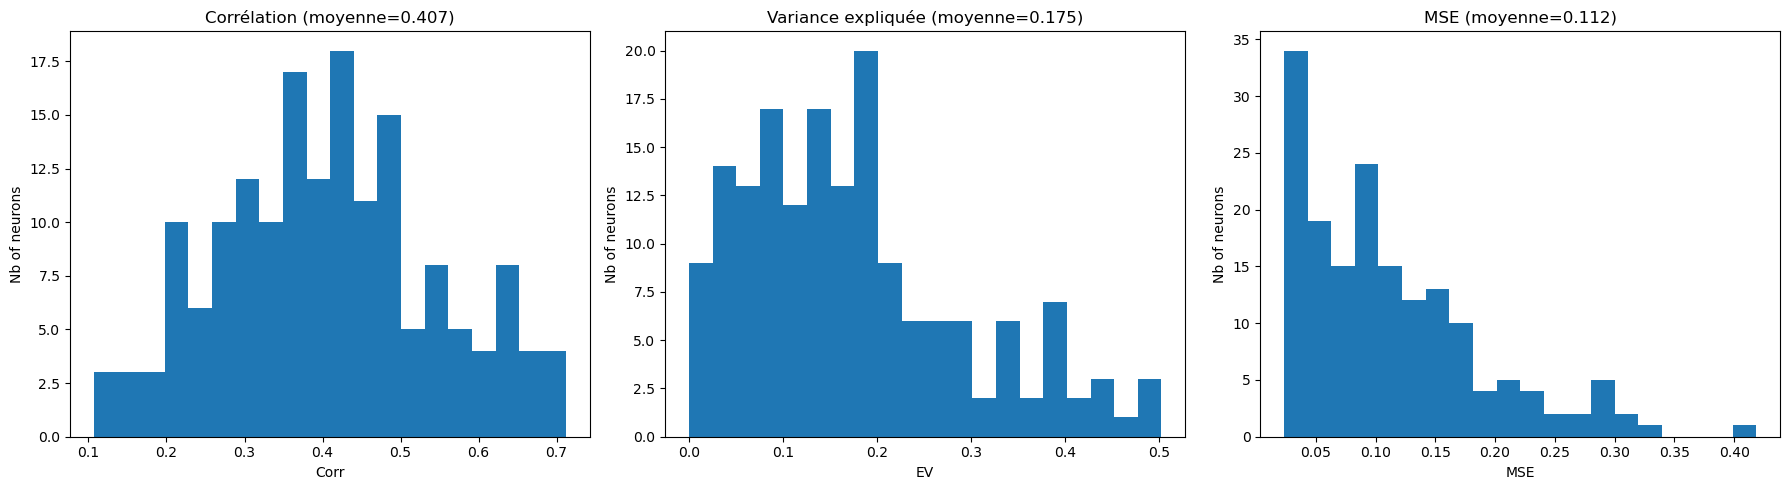

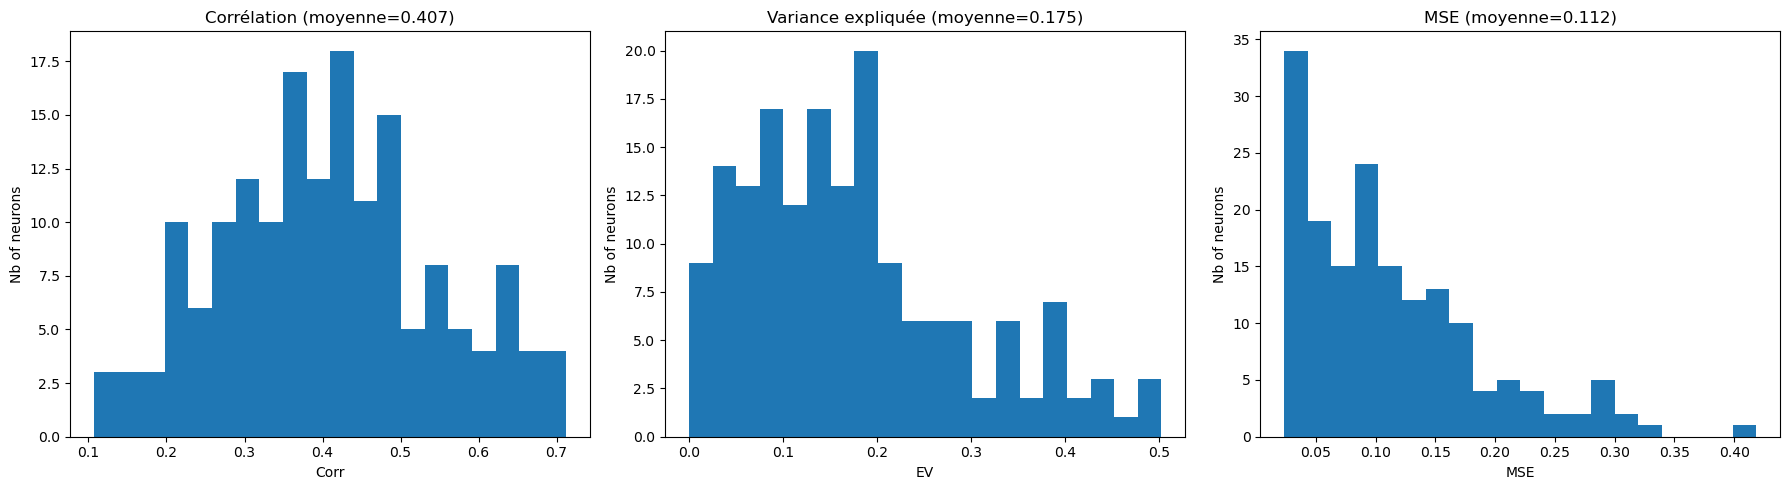

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim

class ObjectToSpikesModel(nn.Module):
    def __init__(self, num_classes, embedding_dim=64, hidden_dim=128, spike_dim=168):
        super().__init__()
        self.embedding = nn.Embedding(num_classes, embedding_dim)
        self.fc1 = nn.Linear(embedding_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, spike_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        
    def forward(self, x):
        x = self.embedding(x)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.dropout(self.relu(self.fc2(x)))
        x = self.fc3(x)
        return x

# Initialisation du modèle
model = ObjectToSpikesModel(num_classes).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Boucle d'entraînement
num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for objects_batch, spikes_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(objects_batch)
        loss = criterion(outputs, spikes_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(val_inputs)
        val_loss = criterion(val_outputs, val_targets)
        
        # Calcul des métriques avec la fonction fournie
        val_metrics = calculate_metrics(val_outputs.cpu().numpy(), val_targets.cpu().numpy())
    
    print(f"Epoch {epoch+1}/{num_epochs}, Loss train: {train_loss/len(train_loader):.4f}, Loss val: {val_loss:.4f}")
    print(f"EV: {val_metrics['explained_variance_mean']:.4f}, Corr: {val_metrics['correlation_mean']:.4f}")

plot_metrics(val_metrics)

In [ ]:

class SpikesDataset(Dataset):

    def __init__(self, stimuli, spikes, device):
        """
        Spike activity for given stimuli.

        Parameters
        ----------
        stimuli : np.array
            Stimuli shown linked with given spikes.
        spikes : np.array
            Corresponding spikes array.
        device : str 
            Computation device.
        """
        self.stimuli = torch.tensor(stimuli, dtype=torch.float32, device=device)
        self.spikes = torch.tensor(spikes, dtype=torch.float32, device=device)

    def __len__(self):
        return len(self.stimuli)

    def __getitem__(self, idx):
        stimulus = self.stimuli[idx]
        spike = self.spikes[idx]
        return stimulus, spike
    
class ActivationsDataset(Dataset):
    def __init__(self, activations, spikes, device):
        """
        Spike activity for given neural activations.

        Parameters
        ----------
        activations : np.array
            Neural activations array linked with given spikes.
        spikes : np.array
            Corresponding spikes array.
        device : str 
            Computation device.
        """
        self.activations = torch.tensor(activations, dtype=torch.float32, device=device)
        self.spikes = torch.tensor(spikes, dtype=torch.float32, device=device)

    def __len__(self):
        return len(self.activations)

    def __getitem__(self, idx):
        activation = self.activations[idx]
        spike = self.spikes[idx]
        return activation, spike


# layers

In [2]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.models.feature_extraction import create_feature_extractor

Using device: cpu


In [3]:

def extract_activations(model, imgs_tr, imgs_val, return_nodes, pca=True):
    """
    Extracts specific layers/nodes/activations from given model when feeding training and validation data.

    Parameters
    ----------
    model : nn.Module
        Model from which to extract internal nodes.
    imgs_tr : torch.tensor
        Training images used for extracting training activations.
    imgs_val : torch.tensor 
        Validation images used for extracting validation activations.
    return_nodes : list
        Nodes to extract from the given model.
    pca : bool
        Whether or not to return principal components from flattened activations.

    Returns
    -------
    activations_tr : list
        Extracted training nodes.
    activations_val : list
        Extracted validation nodes.
    """
    activations_tr = []
    activations_val = []

    for return_node in return_nodes:

        print(f"Extracting {return_node}...")
        # Place hook on wanted layer
        extractor = create_feature_extractor(model, return_nodes={return_node:return_node})
        extractor.eval()

        with torch.no_grad():

            # Forward training set
            activation_tr = extractor(imgs_tr)[return_node]
            if pca:
                activation_tr = activation_tr.flatten(1)
                U, S, V = torch.pca_lowrank(activation_tr, 1000) # pca performed on gpu
                activation_tr = activation_tr @ V
            activations_tr.append(activation_tr.cpu())
            del activation_tr

            # Forward validation set
            activation_val = extractor(imgs_val)[return_node]
            if pca:
                activation_val = activation_val.flatten(1) @ V
            activations_val.append(activation_val.cpu())
            del activation_val
            
        torch.cuda.empty_cache()
        del extractor,

    del model
    print(" ")
    
    return activations_tr, activations_val


In [ ]:
imgs_tr = torch.from_numpy(stimulus_train).to(device)
imgs_val = torch.from_numpy(stimulus_val).to(device)

return_nodes = ['conv1','layer1','layer2','layer3','layer4','avgpool']

print("--- Pretrained Resnet50 --- ")
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)
model = model.to(device)
model.eval()

activations_tr, activations_val = extract_activations(model, imgs_tr, imgs_val, return_nodes)

print("--- Random initialized Resnet50 ---")
model = resnet50() 
model = model.to(device)
model.eval()

rand_activations_tr, rand_activations_val = extract_activations(model, imgs_tr, imgs_val, return_nodes)

--- Pretrained Resnet50 --- 
Extracting conv1...
Extracting layer1...
Extracting layer2...


In [ ]:
for i in range(len(return_nodes)):
    return_node = "resnet_" + return_nodes[i]

    reg = Ridge()
    reg.fit(activations_tr[i], spikes_train)
    y_pred = reg.predict(activations_val[i])
    predictions[return_node] = reg.predict(activations_val[i])

    rand_reg = Ridge()
    rand_reg.fit(rand_activations_tr[i], spikes_train)
    predictions["rand_" + return_node] = rand_reg.predict(rand_activations_val[i])

keys = {
    'resnet_conv1': ['rand_resnet_conv1'],
    'resnet_layer1': ['rand_resnet_layer1'],
    'resnet_layer2': ['rand_resnet_layer2'],
    'resnet_layer3': ['rand_resnet_layer3'], 
    'resnet_layer4': ['rand_resnet_layer4'],
    'resnet_avgpool': ['rand_resnet_avgpool']
    }
evaluate(predictions, spikes_val, keys, ev_range=(-1,1))

Utilisation de l'appareil: cpu
Préparation des données et extraction des activations de la couche 4...
Extraction des activations de la couche 4 pour l'ensemble d'entraînement...
Extraction des activations de la couche 4 pour l'ensemble de validation...
Création des datasets combinés...
Dimensions - Activations: 2048, Spikes: 168
Début de l'entraînement du modèle unifié...
Epoch 1/20
Train Loss: 0.1240, Val Loss: 0.1150
Variance Expliquée - Unifié: 0.1681, Objets: 0.0667, Activations: 0.1362
Epoch 2/20
Train Loss: 0.1075, Val Loss: 0.1067
Variance Expliquée - Unifié: 0.2198, Objets: 0.0853, Activations: 0.1835
Epoch 3/20
Train Loss: 0.1007, Val Loss: 0.1017
Variance Expliquée - Unifié: 0.2386, Objets: 0.0980, Activations: 0.1904
Epoch 4/20
Train Loss: 0.0957, Val Loss: 0.1008
Variance Expliquée - Unifié: 0.2534, Objets: 0.1085, Activations: 0.1942
Epoch 5/20
Train Loss: 0.0919, Val Loss: 0.0978
Variance Expliquée - Unifié: 0.2654, Objets: 0.1117, Activations: 0.2032
Epoch 6/20
Train Lo

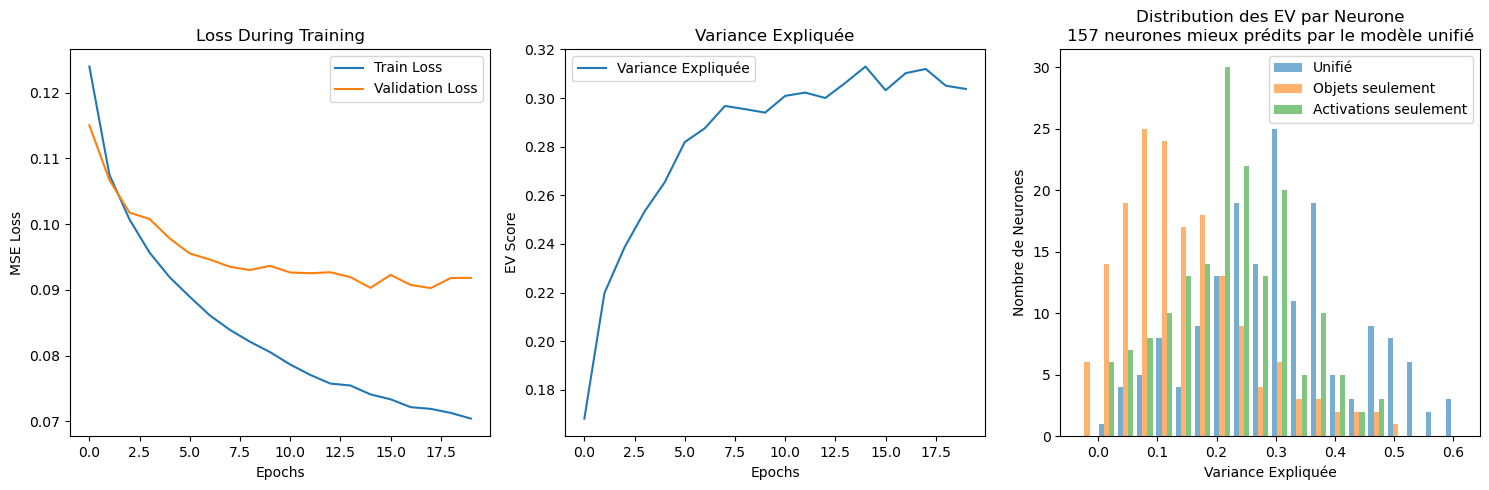

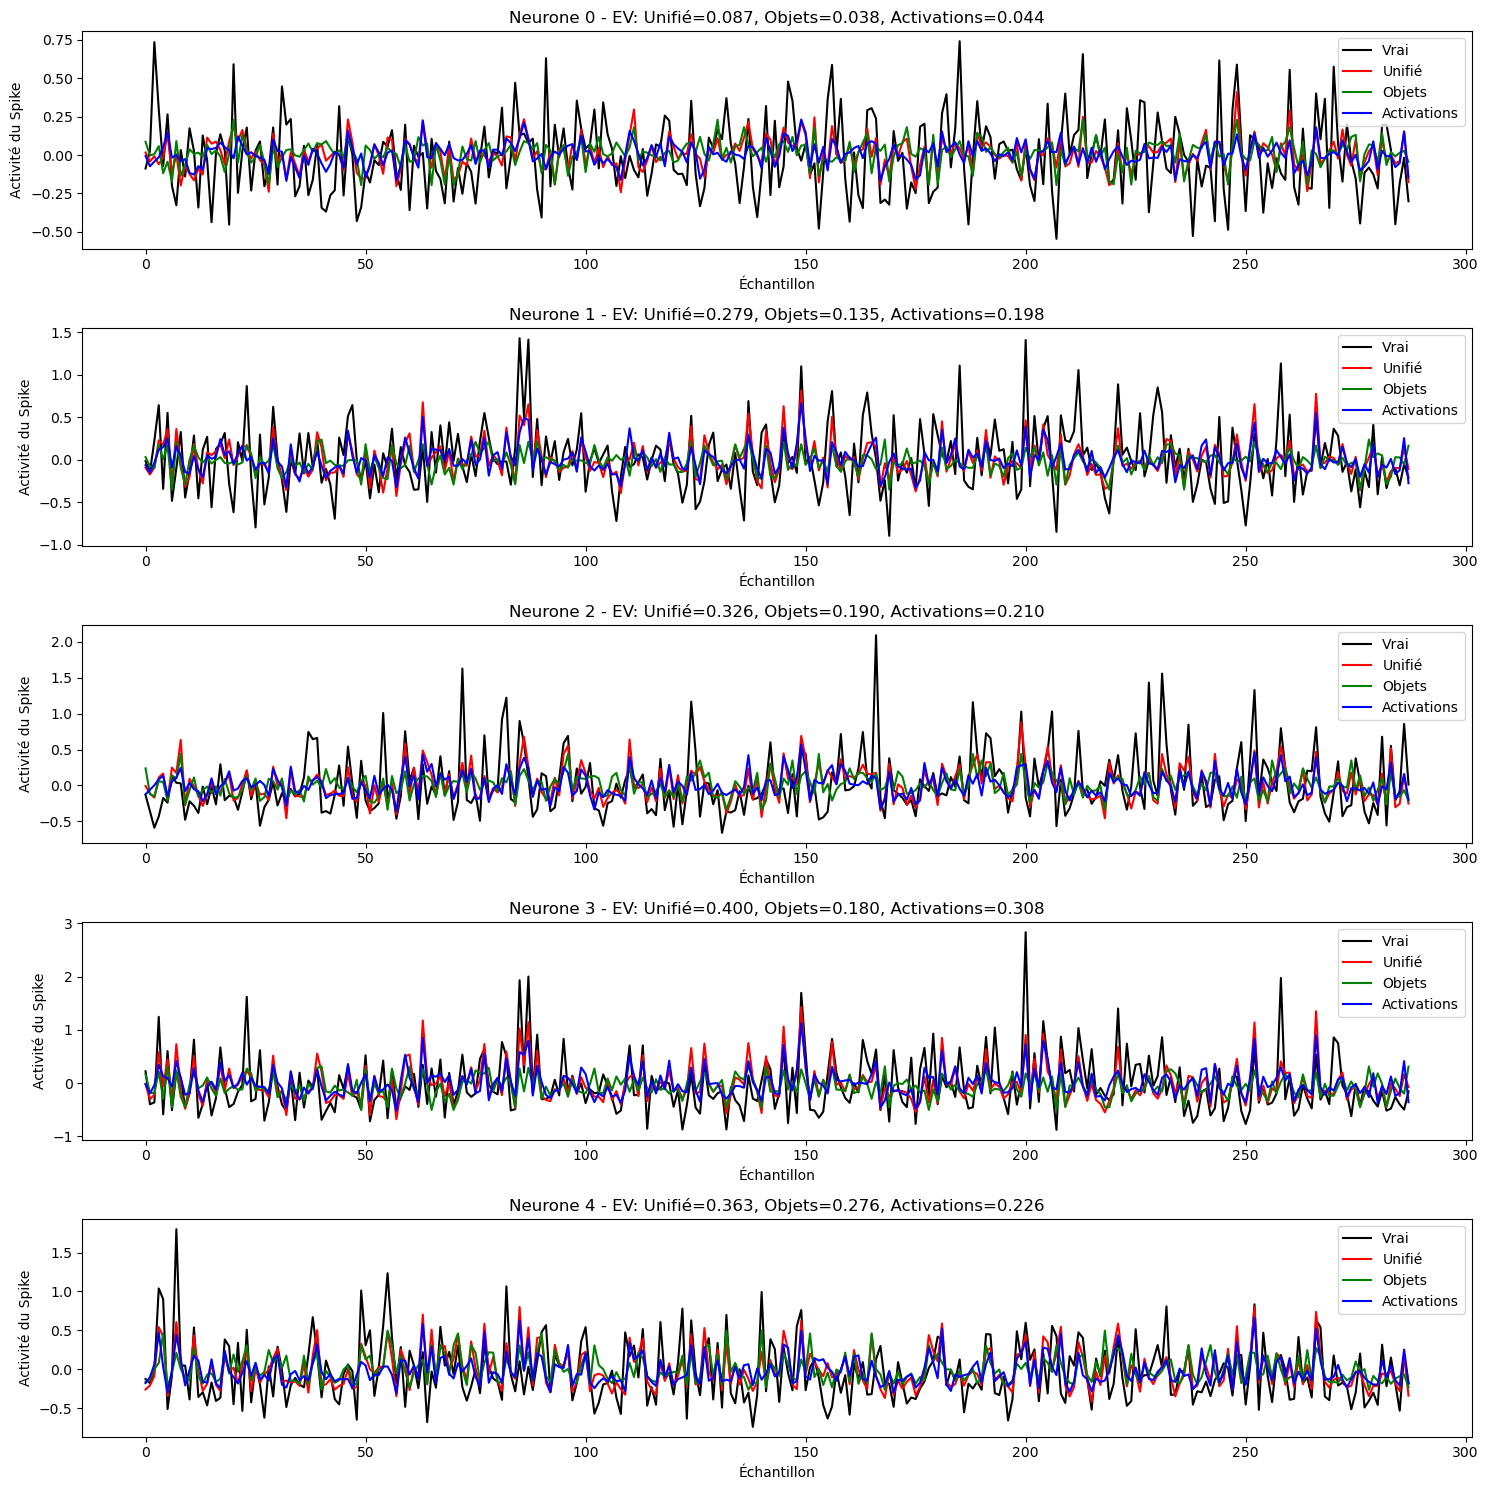

Terminé!


In [1]:
from train_unified_model import main
main()